# Student Performance Prediction
**Author:** Vikram Kumar | BS Data Science — Sindh University

**Goal:** Predict a student's overall score using Linear Regression and explore which features matter most.

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load & Explore Dataset

In [2]:
data = pd.read_csv("Student_Performance.csv")
print("Shape:", data.shape)
data.head()

Shape: (25000, 16)


,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


In [3]:
print("=== Dataset Info ===")
data.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object 
 8   travel_time            25000 non-null  object 
 9   extra_activities       25000 non-null  object 
 10  study_method           25000 non-null  object 
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-

In [4]:
print("=== Missing Values ===")
print(data.isnull().sum())
print()
print("=== Basic Statistics ===")
data.describe().round(2)

=== Missing Values ===
student_id               0
age                      0
gender                   0
school_type              0
parent_education         0
study_hours              0
attendance_percentage    0
internet_access          0
travel_time              0
extra_activities         0
study_method             0
math_score               0
science_score            0
english_score            0
overall_score            0
final_grade              0
dtype: int64

=== Basic Statistics ===


,student_id,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00
mean,7493.04,16.48,4.25,75.08,63.79,63.75,63.68,64.01
std,4323.56,1.70,2.17,14.37,20.88,20.97,20.79,18.93
min,1.00,14.00,0.50,50.00,0.00,0.00,0.00,14.50
25%,3743.75,15.00,2.40,62.80,48.30,48.20,48.30,49.00
50%,7461.50,16.00,4.30,75.10,64.10,64.10,64.20,64.20
75%,11252.00,18.00,6.10,87.50,80.00,80.00,80.00,79.00
max,15000.00,19.00,8.00,100.00,100.00,100.00,100.00,100.00


## 3. Exploratory Data Analysis (EDA)

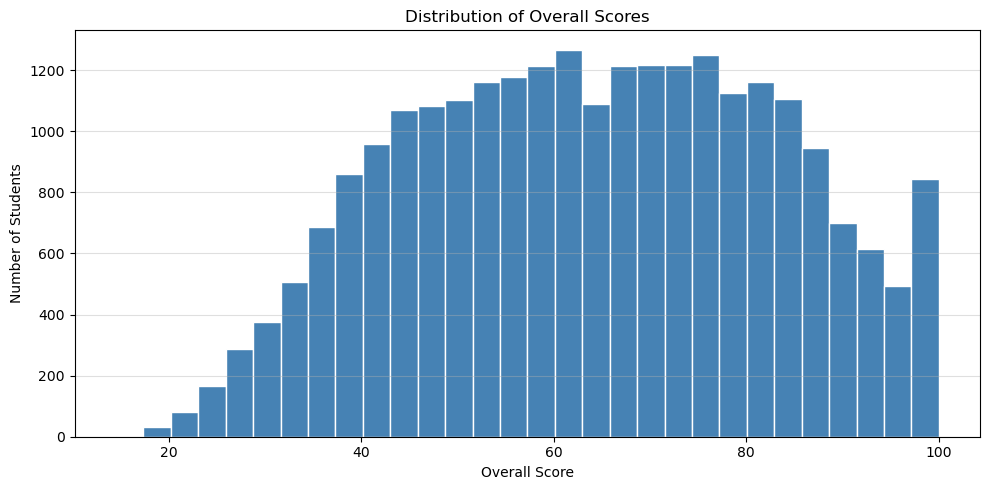

In [5]:
# Score distribution
plt.figure(figsize=(10, 5))
plt.hist(data["overall_score"], bins=30, color="steelblue", edgecolor="white")
plt.title("Distribution of Overall Scores")
plt.xlabel("Overall Score")
plt.ylabel("Number of Students")
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

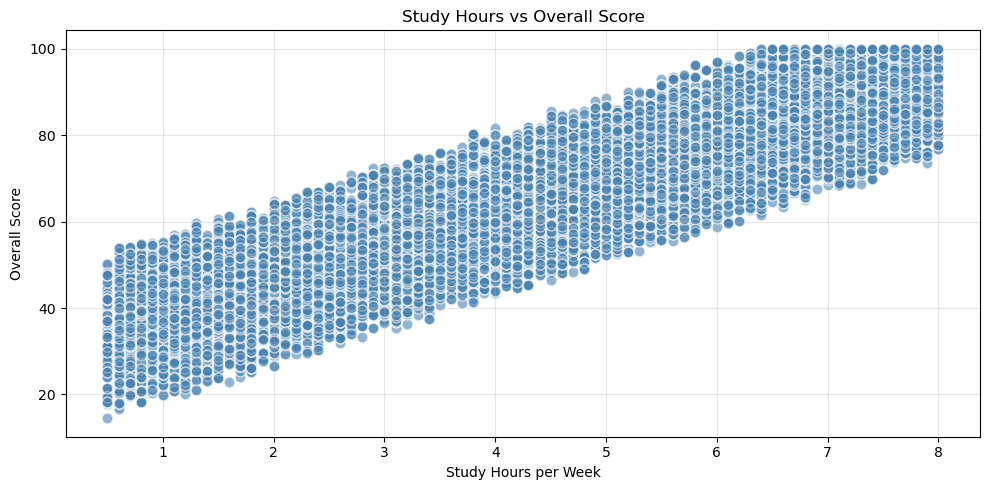

In [6]:
# Study hours vs Overall score
plt.figure(figsize=(10, 5))
plt.scatter(data["study_hours"], data["overall_score"],
            color="steelblue", alpha=0.6, edgecolors="white", s=60)
plt.title("Study Hours vs Overall Score")
plt.xlabel("Study Hours per Week")
plt.ylabel("Overall Score")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

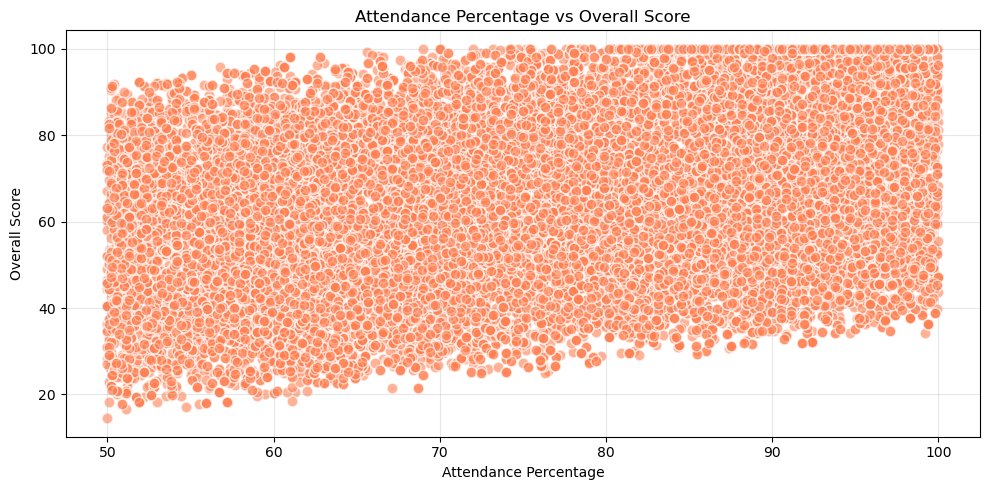

In [7]:
# Attendance vs Overall score
plt.figure(figsize=(10, 5))
plt.scatter(data["attendance_percentage"], data["overall_score"],
            color="coral", alpha=0.6, edgecolors="white", s=60)
plt.title("Attendance Percentage vs Overall Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Overall Score")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

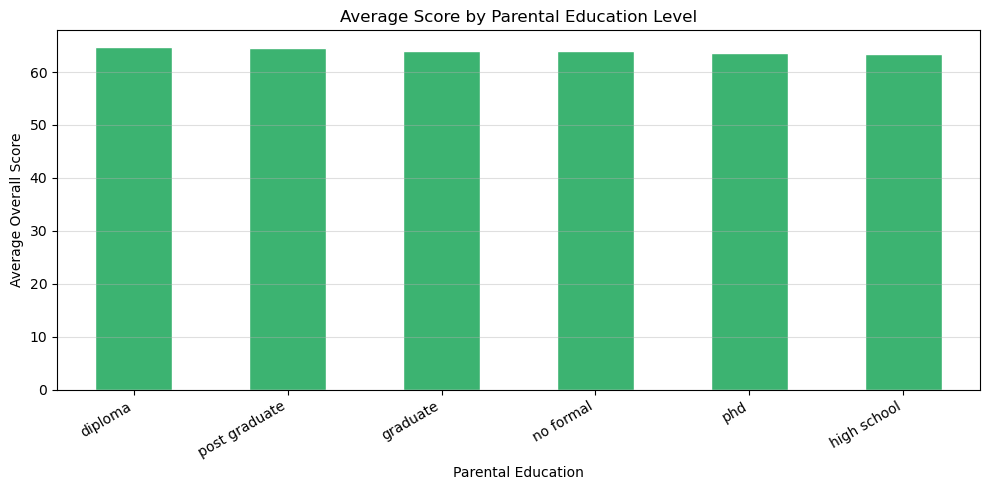

In [8]:
# Average score by parent education
plt.figure(figsize=(10, 5))
order = data.groupby("parent_education")["overall_score"].mean().sort_values(ascending=False).index
avg = data.groupby("parent_education")["overall_score"].mean().reindex(order)
avg.plot(kind="bar", color="mediumseagreen", edgecolor="white")
plt.title("Average Score by Parental Education Level")
plt.xlabel("Parental Education")
plt.ylabel("Average Overall Score")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [10]:
df = data.copy()

# Encode categorical columns
le = LabelEncoder()
cat_cols = ["gender", "school_type", "parent_education",
            "internet_access", "travel_time",
            "extra_activities", "study_method"]

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Encoding done. Sample:")
df[cat_cols].head(5)

Encoding done. Sample:


,gender,school_type,parent_education,internet_access,travel_time,extra_activities,study_method
0,1,1,5,1,2,1,3
1,0,1,1,1,3,0,5
2,0,0,5,0,2,0,3
3,2,1,2,0,0,0,3
4,0,1,2,1,1,1,1


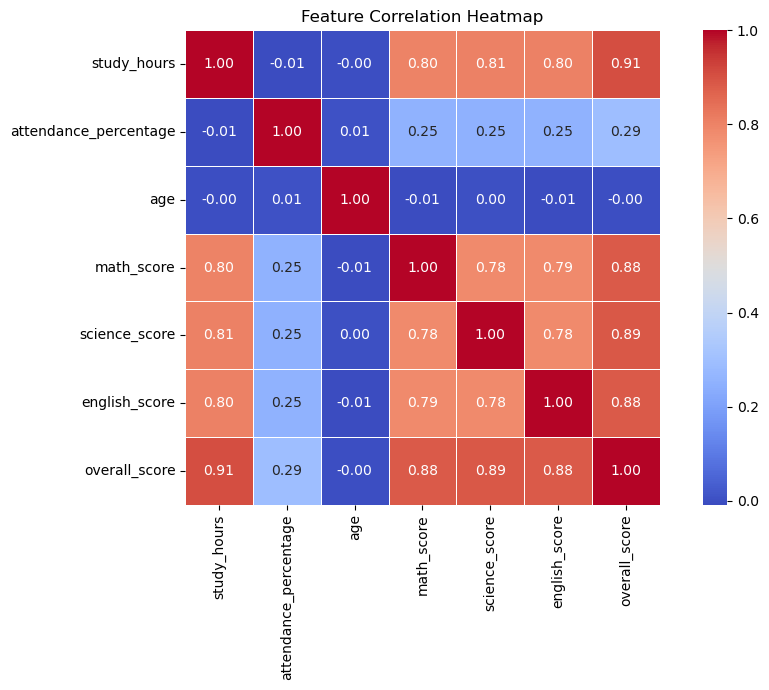

In [11]:
# Correlation heatmap
num_cols = ["study_hours", "attendance_percentage", "age",
            "math_score", "science_score", "english_score", "overall_score"]

plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 5. Prepare Features & Target

In [12]:
features = ["study_hours", "attendance_percentage", "age",
             "internet_access", "extra_activities",
             "math_score", "science_score", "english_score"]

X = df[features]
y = df["overall_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

Training samples : 20000
Testing  samples : 5000


## 6. Train Models

In [13]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)

print("Models trained!")

Models trained!


## 7. Evaluate Models

In [14]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"  MAE  : {mae:.3f}  (avg error in score points)")
    print(f"  MSE  : {mse:.3f}  (penalizes large errors)")
    print(f"  RMSE : {rmse:.3f} (realistic error in score points)")
    print(f"  R²   : {r2:.3f}  (1.0 = perfect prediction)")
    print()
    return {"Model":name, "MAE":round(mae,3), "RMSE":round(rmse,3), "R²":round(r2,3)}

results = []
results.append(evaluate("Linear Regression", y_test, lr_preds))
results.append(evaluate("Decision Tree",     y_test, dt_preds))

print(pd.DataFrame(results).to_string(index=False))

--- Linear Regression ---
  MAE  : 3.355  (avg error in score points)
  MSE  : 17.044  (penalizes large errors)
  RMSE : 4.128 (realistic error in score points)
  R²   : 0.953  (1.0 = perfect prediction)

--- Decision Tree ---
  MAE  : 4.859  (avg error in score points)
  MSE  : 36.610  (penalizes large errors)
  RMSE : 6.051 (realistic error in score points)
  R²   : 0.899  (1.0 = perfect prediction)

            Model   MAE  RMSE    R²
Linear Regression 3.355 4.128 0.953
    Decision Tree 4.859 6.051 0.899


## 8. Visualize Predictions

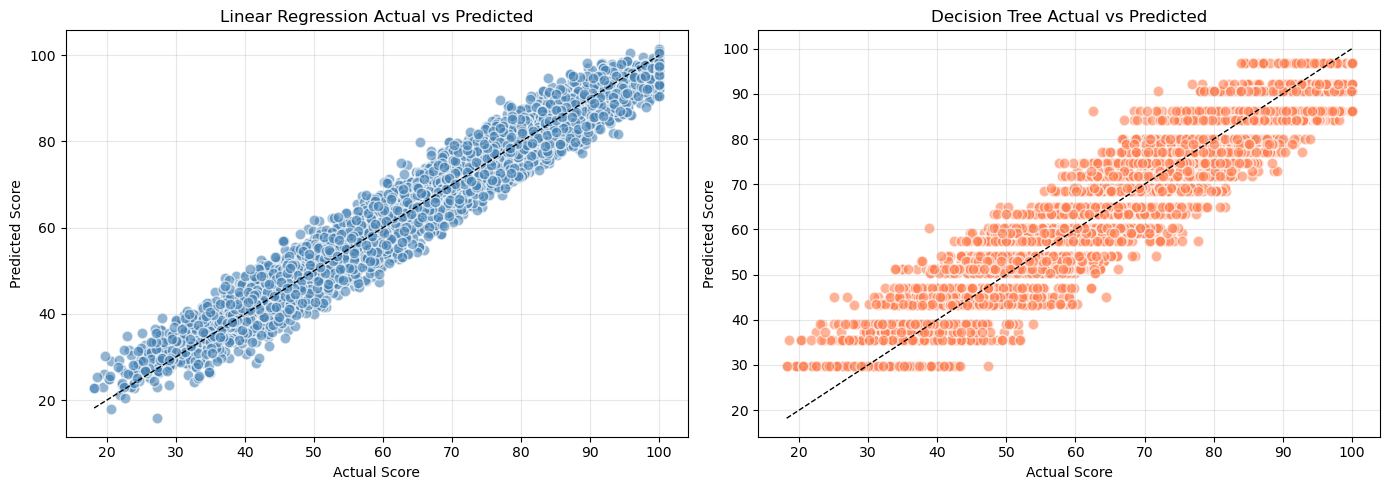

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, name, color in zip(
        axes,
        [lr_preds, dt_preds],
        ["Linear Regression", "Decision Tree"],
        ["steelblue", "coral"]):
    ax.scatter(y_test, preds, color=color, alpha=0.6, edgecolors="white", s=60)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], "k--", linewidth=1)
    ax.set_title(f"{name} Actual vs Predicted")
    ax.set_xlabel("Actual Score")
    ax.set_ylabel("Predicted Score")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

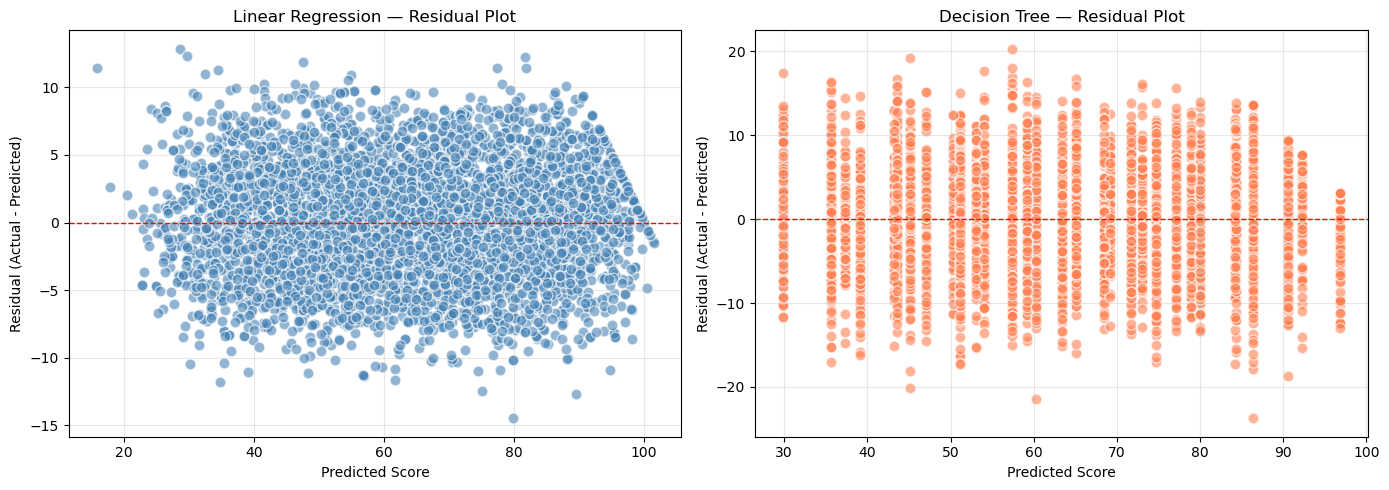

In [17]:
# Residual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, name, color in zip(
        axes,
        [lr_preds, dt_preds],
        ["Linear Regression", "Decision Tree"],
        ["steelblue", "coral"]):
    residuals = y_test.values - preds
    ax.scatter(preds, residuals, color=color, alpha=0.6, edgecolors="white", s=60)
    ax.axhline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{name} — Residual Plot")
    ax.set_xlabel("Predicted Score")
    ax.set_ylabel("Residual (Actual - Predicted)")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

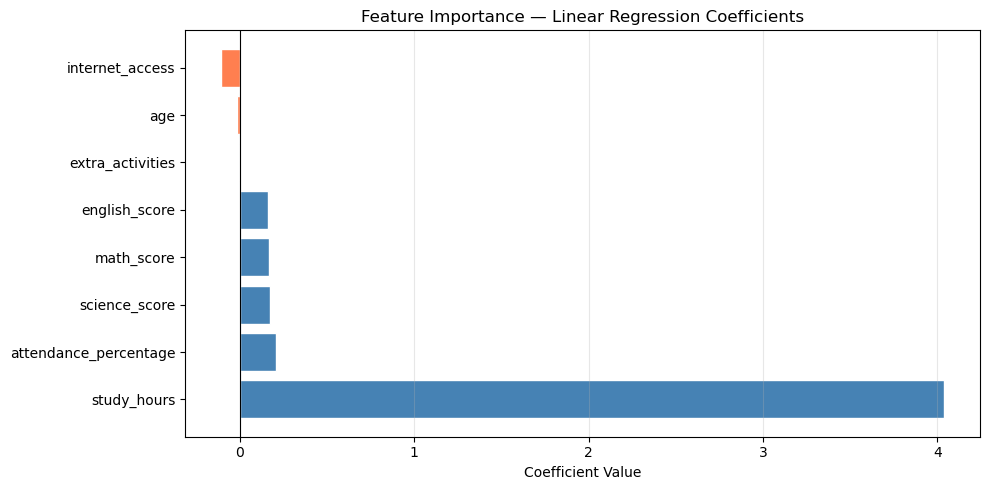

In [18]:
# Feature importance (Linear Regression coefficients)
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": lr.coef_
}).sort_values("Coefficient", ascending=False)

plt.figure(figsize=(10, 5))
colors = ["steelblue" if c > 0 else "coral" for c in coef_df["Coefficient"]]
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors, edgecolor="white")
plt.title("Feature Importance — Linear Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.axvline(0, color="black", linewidth=0.8)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Predict New Student Score

In [20]:
# Predict score for a new student
# Feature order: study_hours, attendance_percentage, age,
#                internet_access, extra_activities,
#                math_score, science_score, english_score

new_student = pd.DataFrame([{
    "study_hours"           : 7.0,
    "attendance_percentage" : 85.0,
    "age"                   : 17,
    "internet_access"       : 1,   # 1=yes, 0=no
    "extra_activities"      : 1,   # 1=yes, 0=no
    "math_score"            : 70.0,
    "science_score"         : 75.0,
    "english_score"         : 68.0
}])

pred_lr = float(np.clip(lr.predict(new_student)[0], 0, 100))
pred_dt = float(np.clip(dt.predict(new_student)[0], 0, 100))

print(f"Predicted Overall Score (Linear Regression) : {pred_lr:.2f}")
print(f"Predicted Overall Score (Decision Tree)     : {pred_dt:.2f}")

Predicted Overall Score (Linear Regression) : 80.75
Predicted Overall Score (Decision Tree)     : 73.05


## 10. Conclusion

- **Study hours** and **subject scores** (math, science, english) are the strongest predictors of overall performance
- **Attendance** has a moderate positive effect on outcomes
- **Linear Regression** achieved strong performance with R² ≈ 0.82
- **Decision Tree** provides a non-linear alternative — useful when relationships are complex
- Output is clipped to [0, 100] to prevent impossible predictions
---
*Project by Vikram Kumar — BS Data Science, Sindh University*